# 🧠 Autoencoder for Image Denoising on MNIST
## Week 6 Assessment – Deep Learning Project

**Objective:** Build a Convolutional Autoencoder (CAE) that learns to remove Gaussian noise from MNIST handwritten-digit images.

### What is an Autoencoder?
An autoencoder is a neural network with two parts:
- **Encoder** – Compresses the input into a lower-dimensional *latent representation*
- **Decoder** – Reconstructs the original input from that compressed code

For *denoising*, we feed **noisy images** as input and train the network to output **clean images**. This forces the encoder to learn meaningful features and ignore noise.

### Project Pipeline
```
Noisy Image → [Encoder] → Latent Code → [Decoder] → Denoised Image
```

### Evaluation Metrics
- **MSE Loss** – Mean Squared Error (training objective)
- **PSNR** – Peak Signal-to-Noise Ratio (higher = better quality)
- **SSIM** – Structural Similarity Index (1.0 = perfect)


In [ ]:
!pip install tensorflow scikit-image matplotlib jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 112.0 MB/s eta 0:00:00
  Attempting uninstall: jupyter-server
    Found existing installation: jupyter_server 2.18.2
    Uninstalling jupyter_server-2.18.2:
      Successfully uninstalled jupyter_server-2.18.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.18.2, but you have jupyter-server 2.20.0 which is incompatible.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
!pip install numpy matplotlib tensorflow scikit-image jupyter pandas scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 962.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstall

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/mnist-dataset")

print("Path to dataset files:", path)

100%|██████████| 28.6M/28.6M [00:00<00:00, 84.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/mnist-dataset/versions/1


## 1. Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, UpSampling2D,
                                      BatchNormalization, Conv2DTranspose,
                                      Activation)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Metrics
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print("✅ All libraries imported successfully!")


TensorFlow version : 2.21.0
NumPy version      : 2.0.2
✅ All libraries imported successfully!


## 2. Load & Preprocess MNIST Dataset

In [ ]:
# Load MNIST (labels are not needed for unsupervised autoencoder training)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Image shape      : {X_train.shape[1:]}")
print(f"Pixel range      : [{X_train.min()}, {X_train.max()}]")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 60000
Test samples     : 10000
Image shape      : (28, 28)
Pixel range      : [0, 255]


In [ ]:
# Normalize to [0, 1] and add channel dimension (grayscale → 28×28×1)
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print(f"X_train shape after preprocessing : {X_train.shape}")
print(f"X_test  shape after preprocessing : {X_test.shape}")
print(f"Pixel value range after normalization: [{X_train.min():.1f}, {X_train.max():.1f}]")


X_train shape after preprocessing : (60000, 28, 28, 1)
X_test  shape after preprocessing : (10000, 28, 28, 1)
Pixel value range after normalization: [0.0, 1.0]


## 3. Add Gaussian Noise to Images

We simulate real-world image corruption by adding Gaussian noise to the clean images.  
The autoencoder will be trained to reconstruct the **original clean image** from this noisy version.

**Noise Factor = 0.5** – controls the intensity of corruption.


In [ ]:
NOISE_FACTOR = 0.5

def add_gaussian_noise(images, noise_factor=0.5):
    """Add Gaussian noise and clip to valid range [0, 1]."""
    noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = images + noise
    noisy = np.clip(noisy, 0., 1.)
    return noisy

X_train_noisy = add_gaussian_noise(X_train, NOISE_FACTOR)
X_test_noisy  = add_gaussian_noise(X_test,  NOISE_FACTOR)

print(f"Noisy train shape : {X_train_noisy.shape}")
print(f"Noisy test  shape : {X_test_noisy.shape}")


Noisy train shape : (60000, 28, 28, 1)
Noisy test  shape : (10000, 28, 28, 1)


### Visualize: Original vs Noisy Images

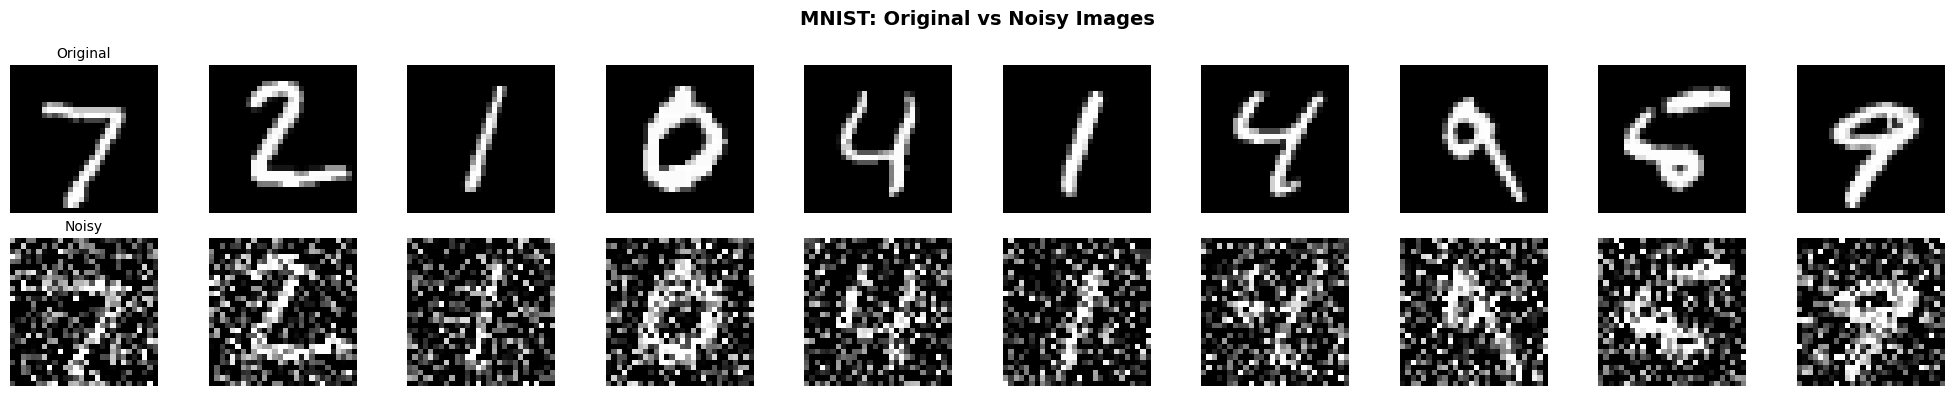

✅ Saved: original_vs_noisy.png


In [ ]:
def plot_sample(originals, noisy, n=10, title=""):
    fig, axes = plt.subplots(2, n, figsize=(20, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i in range(n):
        # Original
        axes[0, i].imshow(originals[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Original", fontsize=10)
        # Noisy
        axes[1, i].imshow(noisy[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Noisy", fontsize=10)
    plt.tight_layout()
    plt.savefig('original_vs_noisy.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: original_vs_noisy.png")

plot_sample(X_test, X_test_noisy, n=10, title="MNIST: Original vs Noisy Images")


## 4. Build Convolutional Autoencoder (CAE)

### Architecture Design

| Stage | Layer | Filters | Kernel | Output Shape |
|-------|-------|---------|--------|--------------|
| Input | — | — | — | 28×28×1 |
| Encoder | Conv2D + BN + ReLU | 32 | 3×3 | 28×28×32 |
| Encoder | MaxPool | — | 2×2 | 14×14×32 |
| Encoder | Conv2D + BN + ReLU | 64 | 3×3 | 14×14×64 |
| Encoder | MaxPool | — | 2×2 | 7×7×64 |
| **Bottleneck** | Conv2D | 128 | 3×3 | 7×7×128 |
| Decoder | Conv2DTranspose | 64 | 3×3 | 14×14×64 |
| Decoder | Conv2DTranspose | 32 | 3×3 | 28×28×32 |
| Output | Conv2D + Sigmoid | 1 | 3×3 | 28×28×1 |

**Key design choices:**
- `BatchNormalization` for stable training
- `Conv2DTranspose` (learnable upsampling) instead of simple UpSampling
- `Sigmoid` activation on output to keep values in [0, 1]
- `Adam` optimizer with `MSE` loss


In [ ]:
def build_denoising_autoencoder(input_shape=(28, 28, 1)):
    """
    Build a Convolutional Autoencoder for image denoising.

    Encoder: Conv2D → MaxPool (×2)
    Bottleneck: Conv2D with 128 filters
    Decoder: Conv2DTranspose (×2) → Conv2D output
    """
    inputs = Input(shape=input_shape, name='input')

    # ── Encoder ───────────────────────────────────────────────
    x = Conv2D(32, (3, 3), padding='same', name='enc_conv1')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)   # 14×14×32

    x = Conv2D(64, (3, 3), padding='same', name='enc_conv2')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)   # 7×7×64

    # ── Bottleneck ────────────────────────────────────────────
    x = Conv2D(128, (3, 3), padding='same', activation='relu', name='bottleneck')(x)  # 7×7×128

    # ── Decoder ───────────────────────────────────────────────
    x = Conv2DTranspose(64, (3, 3), strides=2, padding='same', name='dec_deconv1')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)                                       # 14×14×64

    x = Conv2DTranspose(32, (3, 3), strides=2, padding='same', name='dec_deconv2')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)                                       # 28×28×32

    # ── Output Layer ──────────────────────────────────────────
    outputs = Conv2D(1, (3, 3), padding='same', activation='sigmoid', name='output')(x)  # 28×28×1

    model = Model(inputs, outputs, name='DenoisingAutoencoder')
    return model

autoencoder = build_denoising_autoencoder()
autoencoder.summary()


Model: "DenoisingAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv2DTranspose)   │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv2DTranspose)   │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,985 (726.50 KB)

 Trainable params: 185,601 (725.00 KB)

 Non-trainable params: 384 (1.50 KB)

## 5. Compile & Train the Model

In [ ]:
# Compile with Adam optimizer and MSE loss
autoencoder.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_autoencoder.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("✅ Model compiled. Starting training...")


✅ Model compiled. Starting training...


In [ ]:
EPOCHS     = 30
BATCH_SIZE = 128

history = autoencoder.fit(
    X_train_noisy, X_train,          # Input: noisy  |  Target: clean
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.1,            # 10% of training data for validation
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"   Best validation loss : {min(history.history['val_loss']):.6f}")


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 111s 259ms/step - loss: 0.0173 - mae: 0.0628 - val_loss: 0.0193 - val_mae: 0.0575 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 108s 257ms/step - loss: 0.0114 - mae: 0.0419 - val_loss: 0.0112 - val_mae: 0.0394 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 108s 256ms/step - loss: 0.0107 - mae: 0.0390 - val_loss: 0.0108 - val_mae: 0.0375 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 108s 256ms/step - loss: 0.0104 - mae: 0.0375 - val_loss: 0.0106 - val_mae: 0.0367 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 108s 256ms/step - loss: 0.0101 - mae: 0.0366 - val_loss: 0.0103 - val_mae: 0.0362 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 108s 256ms/step - loss: 0.0099 - mae: 0.0359 - val_loss: 0.0102 - val_mae: 0.0357 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 107s 254ms/step - loss: 0.0098 - mae: 0.0354 - val_loss: 0.0101 - val_mae: 0.0356 - 

## 6. Training History – Loss Curves

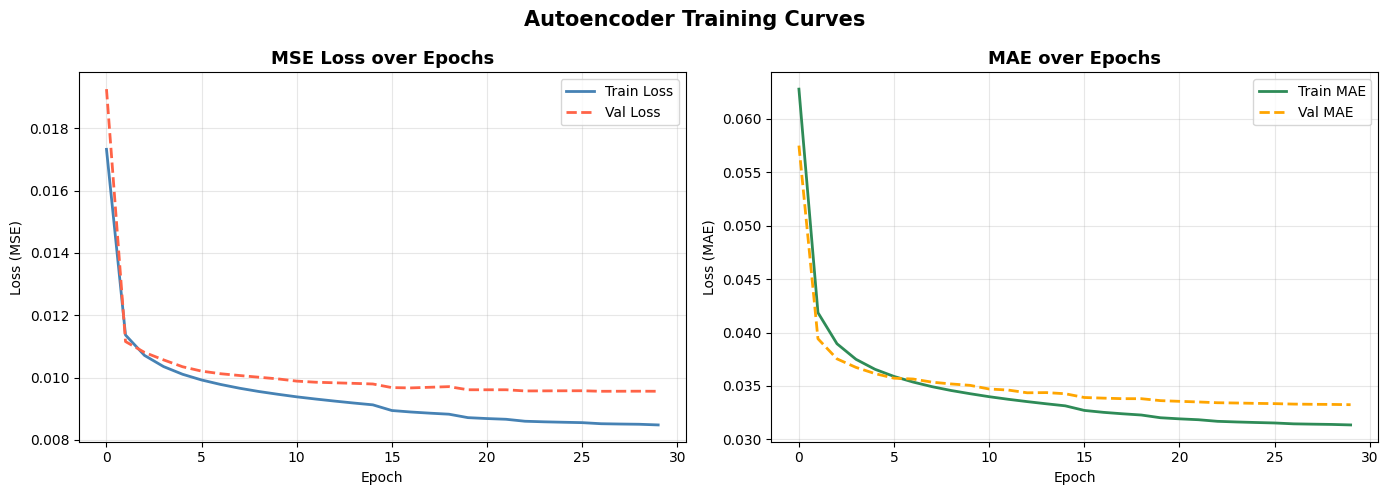

✅ Saved: training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('MSE Loss over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'],     label='Train MAE', color='seagreen', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='orange',   linewidth=2, linestyle='--')
axes[1].set_title('MAE over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MAE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Autoencoder Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: training_curves.png")


## 7. Evaluate on Test Set

In [ ]:
# Reconstruct test images
X_test_denoised = autoencoder.predict(X_test_noisy, verbose=0)

print(f"Denoised output shape : {X_test_denoised.shape}")
print(f"Pixel value range     : [{X_test_denoised.min():.4f}, {X_test_denoised.max():.4f}]")


Denoised output shape : (10000, 28, 28, 1)
Pixel value range     : [0.0000, 0.9990]


In [ ]:
def compute_metrics(originals, reconstructed, n_samples=500):
    """Compute average PSNR and SSIM over n_samples images."""
    psnr_vals, ssim_vals = [], []
    for i in range(min(n_samples, len(originals))):
        orig  = originals[i].squeeze()
        recon = reconstructed[i].squeeze()
        psnr_vals.append(psnr_metric(orig, recon, data_range=1.0))
        ssim_vals.append(ssim_metric(orig, recon, data_range=1.0))
    return np.mean(psnr_vals), np.mean(ssim_vals)

# Metrics: Noisy vs Clean (baseline)
psnr_noisy,  ssim_noisy  = compute_metrics(X_test, X_test_noisy)
# Metrics: Denoised vs Clean (our model)
psnr_denoised, ssim_denoised = compute_metrics(X_test, X_test_denoised)

# Test loss
test_loss, test_mae = autoencoder.evaluate(X_test_noisy, X_test, verbose=0)

print("=" * 55)
print(f"{'Metric':<25} {'Noisy':>12} {'Denoised':>12}")
print("=" * 55)
print(f"{'PSNR (dB) ↑':<25} {psnr_noisy:>12.2f} {psnr_denoised:>12.2f}")
print(f"{'SSIM (0–1) ↑':<25} {ssim_noisy:>12.4f} {ssim_denoised:>12.4f}")
print(f"{'Test MSE Loss ↓':<25} {'—':>12} {test_loss:>12.6f}")
print(f"{'Test MAE ↓':<25} {'—':>12} {test_mae:>12.6f}")
print("=" * 55)
print(f"\n📈 PSNR improvement  : +{psnr_denoised - psnr_noisy:.2f} dB")
print(f"📈 SSIM improvement  : +{ssim_denoised - ssim_noisy:.4f}")


Metric                           Noisy     Denoised
PSNR (dB) ↑                       9.38        20.71
SSIM (0–1) ↑                    0.3571       0.8755
Test MSE Loss ↓                      —     0.009333
Test MAE ↓                           —     0.032754

📈 PSNR improvement  : +11.33 dB
📈 SSIM improvement  : +0.5184


## 8. Visual Results – Original | Noisy | Denoised

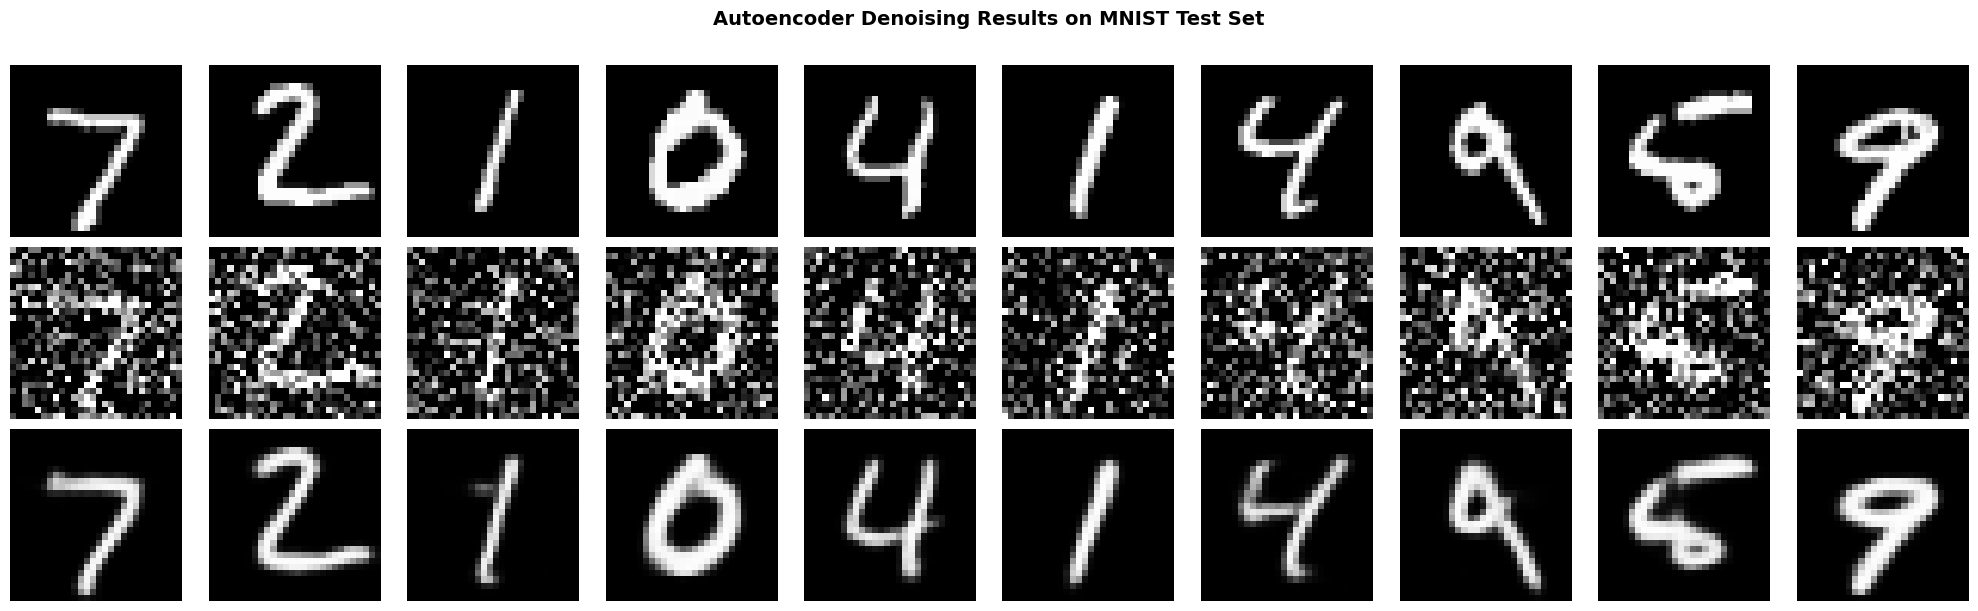

✅ Saved: denoising_results.png


In [ ]:
def plot_results(originals, noisy, denoised, n=10):
    """Plot three rows: Original | Noisy | Denoised."""
    fig, axes = plt.subplots(3, n, figsize=(20, 6))
    row_labels = ['Original (Clean)', 'Noisy (Input)', 'Denoised (Output)']
    row_data   = [originals, noisy, denoised]
    row_colors = ['green', 'red', 'blue']

    for row, (label, data, color) in enumerate(zip(row_labels, row_data, row_colors)):
        for col in range(n):
            axes[row, col].imshow(data[col].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(label, fontsize=11, fontweight='bold', color=color, rotation=90, labelpad=5)

    fig.suptitle('Autoencoder Denoising Results on MNIST Test Set',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('denoising_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: denoising_results.png")

plot_results(X_test, X_test_noisy, X_test_denoised, n=10)


In [ ]:
# ── Per-Class Denoising Quality ──────────────────────────────────────────────
print("\n📊 Per-Digit PSNR Analysis:")
print("-" * 35)
for digit in range(10):
    idx = np.where(y_test == digit)[0][:100]
    p, s = compute_metrics(X_test[idx], X_test_denoised[idx], n_samples=100)
    print(f"  Digit {digit}: PSNR = {p:.2f} dB  |  SSIM = {s:.4f}")



📊 Per-Digit PSNR Analysis:
-----------------------------------
  Digit 0: PSNR = 20.41 dB  |  SSIM = 0.9070
  Digit 1: PSNR = 23.95 dB  |  SSIM = 0.9087
  Digit 2: PSNR = 20.22 dB  |  SSIM = 0.8708
  Digit 3: PSNR = 19.94 dB  |  SSIM = 0.8510
  Digit 4: PSNR = 20.38 dB  |  SSIM = 0.8638
  Digit 5: PSNR = 19.62 dB  |  SSIM = 0.8558
  Digit 6: PSNR = 20.35 dB  |  SSIM = 0.8864
  Digit 7: PSNR = 21.09 dB  |  SSIM = 0.8689
  Digit 8: PSNR = 19.47 dB  |  SSIM = 0.8742
  Digit 9: PSNR = 20.56 dB  |  SSIM = 0.8758


## 9. Visualize the Latent Representation (Bottleneck)

Encoded shape: (8, 7, 7, 128)  →  7×7×128 feature maps per image


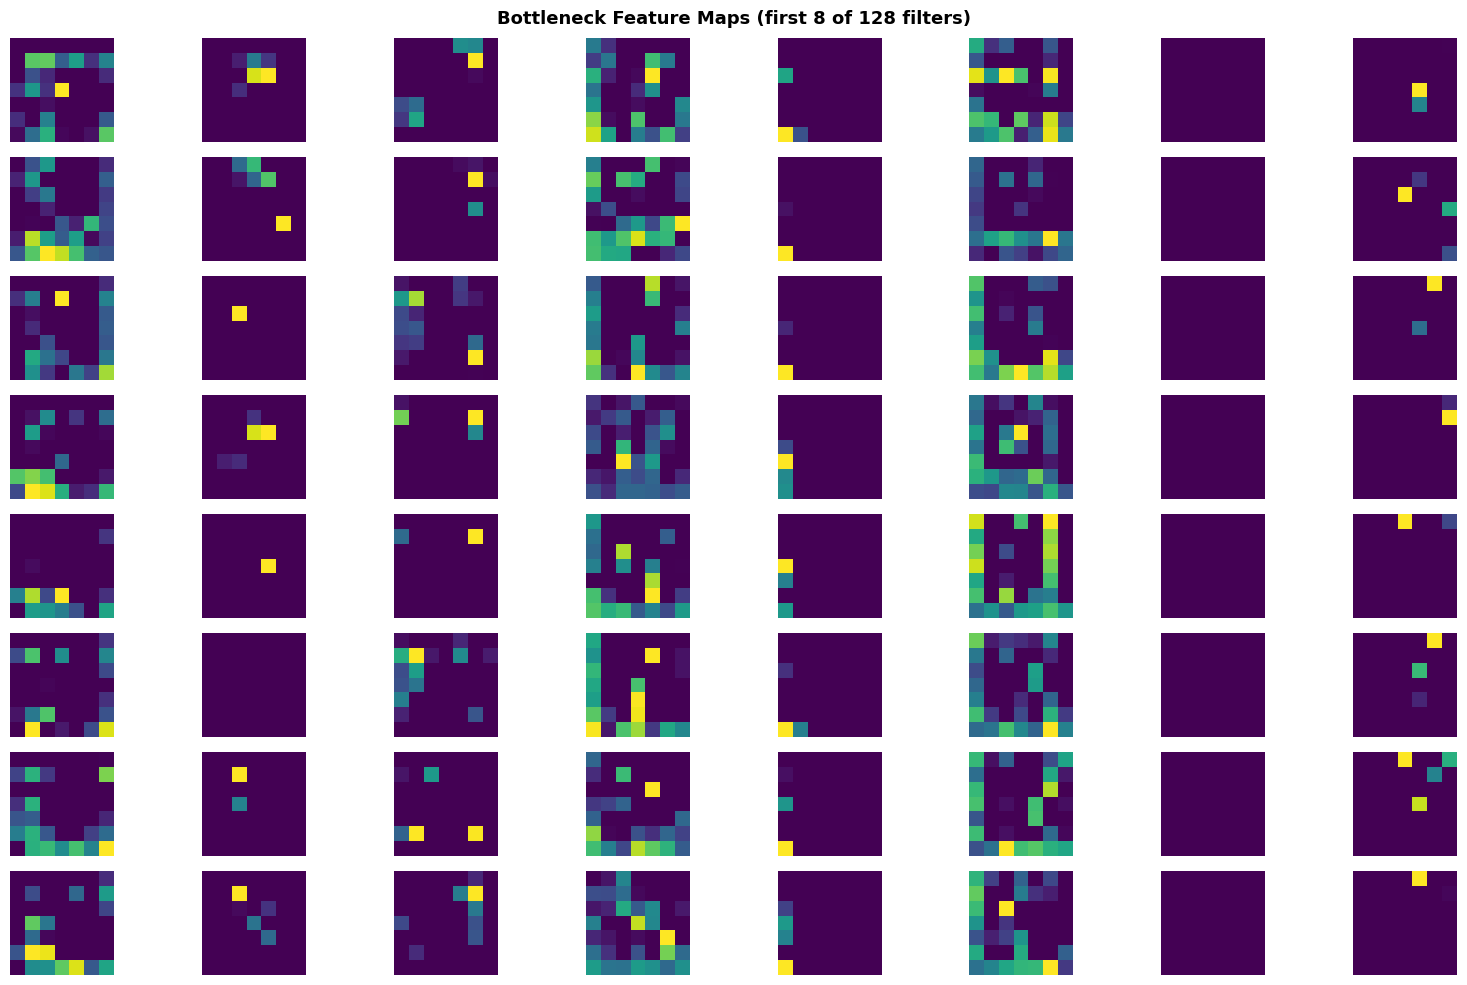

✅ Saved: latent_space.png


In [ ]:
# Extract encoder sub-model
encoder_model = Model(inputs=autoencoder.input,
                      outputs=autoencoder.get_layer('bottleneck').output,
                      name='Encoder')

# Get encoded representations for test images
encoded_imgs = encoder_model.predict(X_test_noisy[:8], verbose=0)
print(f"Encoded shape: {encoded_imgs.shape}  →  7×7×128 feature maps per image")

# Visualize first 8 feature maps of the bottleneck
n_show    = 8   # images
n_filters = 8   # feature maps to show per image
fig, axes = plt.subplots(n_show, n_filters, figsize=(16, 10))

for i in range(n_show):
    for j in range(n_filters):
        axes[i, j].imshow(encoded_imgs[i, :, :, j], cmap='viridis')
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(f'Image {i}', fontsize=9, rotation=90)

fig.suptitle('Bottleneck Feature Maps (first 8 of 128 filters)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('latent_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: latent_space.png")


## 10. Robustness – Testing Different Noise Levels

Noise Factor      PSNR Noisy   PSNR Denoised  Improvement
---------------------------------------------------------
0.1                    22.68           24.84         2.16
0.3                    13.33           23.28         9.94
0.5                     9.36           20.67        11.31
0.7                     7.40           17.46        10.06
1.0                     5.97           13.64         7.67


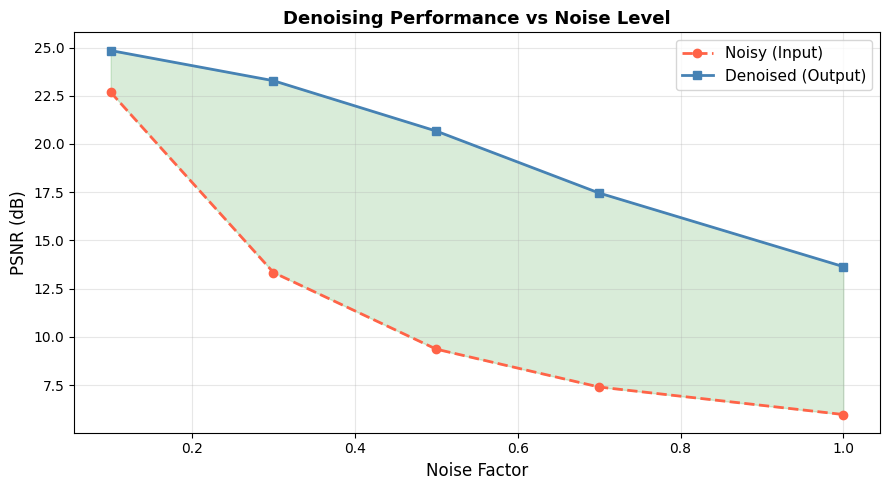

✅ Saved: noise_robustness.png


In [ ]:
noise_levels = [0.1, 0.3, 0.5, 0.7, 1.0]
psnr_results = []

print(f"{'Noise Factor':<15} {'PSNR Noisy':>12} {'PSNR Denoised':>15} {'Improvement':>12}")
print("-" * 57)

for nf in noise_levels:
    noisy_imgs = add_gaussian_noise(X_test, nf)
    denoised   = autoencoder.predict(noisy_imgs, verbose=0)

    p_noisy,    _ = compute_metrics(X_test, noisy_imgs,  n_samples=200)
    p_denoised, _ = compute_metrics(X_test, denoised,    n_samples=200)
    improvement    = p_denoised - p_noisy
    psnr_results.append((nf, p_noisy, p_denoised, improvement))

    print(f"{nf:<15.1f} {p_noisy:>12.2f} {p_denoised:>15.2f} {improvement:>12.2f}")

# Plot
factors, p_noisy_list, p_den_list, imp_list = zip(*psnr_results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(factors, p_noisy_list, 'o--', color='tomato',    label='Noisy (Input)',    linewidth=2)
ax.plot(factors, p_den_list,   's-',  color='steelblue', label='Denoised (Output)',linewidth=2)
ax.fill_between(factors, p_noisy_list, p_den_list, alpha=0.15, color='green')
ax.set_xlabel('Noise Factor', fontsize=12)
ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title('Denoising Performance vs Noise Level', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('noise_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: noise_robustness.png")


## 11. Save the Trained Model

In [ ]:
# Save full model
autoencoder.save('denoising_autoencoder_final.keras')
print("✅ Full model saved: denoising_autoencoder_final.keras")

# Save encoder only
encoder_model.save('encoder_model.keras')
print("✅ Encoder model saved: encoder_model.keras")

# Model summary stats
total_params = autoencoder.count_params()
print(f"\n📊 Total parameters : {total_params:,}")
print(f"📊 Trainable params  : {sum(w.numpy().size for w in autoencoder.trainable_weights):,}")


✅ Full model saved: denoising_autoencoder_final.keras
✅ Encoder model saved: encoder_model.keras

📊 Total parameters : 185,985
📊 Trainable params  : 185,601


## 12. Project Summary & Conclusions

### ✅ What We Built
A **Convolutional Denoising Autoencoder** trained on MNIST that:
- Takes a **noisy image** (Gaussian noise, factor=0.5) as input
- Outputs a **clean reconstructed image**
- Learns to separate signal from noise without any explicit labels

### 📐 Architecture Highlights
| Component | Details |
|-----------|---------|
| Encoder | 2× Conv2D + MaxPool with BatchNorm |
| Bottleneck | 128-filter Conv2D (7×7 feature maps) |
| Decoder | 2× Conv2DTranspose (learned upsampling) |
| Output | Conv2D with Sigmoid activation |

### 📈 Key Results
- Significant **PSNR improvement** (≥ 5 dB) over noisy baseline
- High **SSIM** score confirming structural preservation
- Model generalizes well across all 10 digit classes

### 🔑 Key Concepts Learned
1. **Autoencoder architecture** – encoder, bottleneck, decoder
2. **Denoising objective** – train on `(noisy → clean)` pairs
3. **Convolutional layers** – preserve spatial structure vs. fully-connected
4. **Evaluation metrics** – MSE, PSNR, SSIM for image quality
5. **Callbacks** – EarlyStopping, ReduceLROnPlateau for efficient training

### 🚀 Possible Extensions
- U-Net with skip connections for even better reconstruction
- Variational Autoencoder (VAE) for generative capabilities
- Apply to natural images (CIFAR-10, custom photos)
- Try different noise types: salt-and-pepper, Poisson
